# Inkar einlesen

by Matthias Dorner

### Setup

In [2]:
# Imports 
import pandas as pd
from pathlib import Path
import pyarrow
from typing import Iterable, Optional, Tuple, Union
from pathlib import Path
import urllib.request
import py7zr
from pathlib import Path
import urllib.request
import zipfile
import shutil
import subprocess

In [3]:
# Paths for input and output files
inkar_path = Path(r"data\inkar_2025.csv")
out_path_parquet = inkar_path.with_name("inkar_bayern_nordbayern.parquet")
out_path_csv = inkar_path.with_name("inkar_bayern_nordbayern.csv")

### Definitionen 

In [50]:
# Filter Raumbezug values
#valid_raumbezug = ["Gemeinden", "Gemeindeverbände (Verwaltungsgemeinschaft)","Kreise", "Regierungsbezirke", "Bundesländer"] # Extended list for Gemeinden 
valid_raumbezug = ["Kreise", "Regierungsbezirke", "Bundesländer", "Gemeinden"]

# Filter Regierungsbezirke in Nordbayern: Oberpfalz, Oberfranken, Unterfranken, Mittelfranken
regierungsbezirke_kennziffern = ["093", "094", "095", "096"]

### Download & Extraktion (wichtig: nur einmal ausführen, vorher 7Zip installieren)

In [7]:
# Paths & URL
download_url = "https://www.bbr-server.de/imagemap/inkar/download/inkar_2025.zip"
extract_folder = Path("data/inkar")
zip_file_path = extract_folder / "inkar_2025.zip"
csv_file_path = extract_folder / "inkar_2025.csv"

extract_folder.mkdir(parents=True, exist_ok=True)


# 1) Exit early if CSV already exists
if csv_file_path.exists():
    print(f"CSV already exists → nothing to do:\n  {csv_file_path}")
    inkar_path = csv_file_path

else:
    # 2) Download ZIP only if missing
    if zip_file_path.exists():
        print(f"ZIP already exists → skipping download:\n  {zip_file_path}")
    else:
        print(f"Downloading {download_url}...")
        urllib.request.urlretrieve(download_url, zip_file_path)

    # 3) Try built-in zipfile first
    extracted = False
    try:
        print("Trying built-in zipfile extraction...")
        with zipfile.ZipFile(zip_file_path, "r") as zf:
            zf.extractall(extract_folder)
        extracted = True
    except Exception as e:
        print(f"Built-in extraction failed ({type(e).__name__}: {e})")

    # 4) Fallback to 7-Zip if needed
    if not extracted:
        print("Falling back to 7-Zip extraction...")

        seven_zip = (
            shutil.which("7z")
            or shutil.which("7za")
            or (r"C:\Program Files\7-Zip\7z.exe" if Path(r"C:\Program Files\7-Zip\7z.exe").exists() else None)
        )

        if not seven_zip:
            raise RuntimeError(
                "ZIP uses LZMA compression but Python lacks lzma support.\n"
                "Install 7-Zip or reinstall Python from python.org."
            )

        subprocess.run(
            [seven_zip, "x", str(zip_file_path), f"-o{extract_folder}", "-y"],
            check=True
        )

    # 5) Resolve CSV robustly
    csv_candidates = list(extract_folder.rglob("*.csv"))
    if not csv_candidates:
        raise FileNotFoundError("No CSV file found after extraction.")

    # prefer exact match, fallback to first CSV
    inkar_path = (
        csv_file_path
        if csv_file_path.exists()
        else next((p for p in csv_candidates if "inkar" in p.name.lower()), csv_candidates[0])
    )

    print(f"CSV extracted to:\n  {inkar_path}")

# Final path
print(f"Inkar file ready at:\n  {inkar_path}")


ZIP already exists → skipping download:
  data\inkar\inkar_2025.zip
Trying built-in zipfile extraction...
Built-in extraction failed (NotImplementedError: That compression method is not supported)
Falling back to 7-Zip extraction...
CSV extracted to:
  data\inkar\inkar_2025.csv
Inkar file ready at:
  data\inkar\inkar_2025.csv


In [51]:
inkar_path = "data/inkar/inkar_2025.csv"

### Einlesen in chunks für große Dateien

In [52]:
# Load Inkar data in chunks
chunksize = 500_000

chunks = []
for chunk in pd.read_csv(
    inkar_path,
    sep=";",
    chunksize=chunksize,
    dtype={"Kennziffer":"string","Zeitbezug":"string","Wert":"string","Raumbezug":"string","ID":"string"},
):
    # Filter Kreise in Bavaria (= Kennziffer "09xxxx")
    chunk = chunk[chunk["Kennziffer"].str.startswith("09", na=False)] 
    
    # Filter on valid list of Raumbezug
    chunk = chunk[chunk["Raumbezug"].isin(valid_raumbezug)]

    # Replace commas with dots in "Wert" column and convert to numeric
    chunk["Wert"] = pd.to_numeric(chunk["Wert"].str.replace(",", "."), errors="coerce")
    
    if chunk.empty:
        continue

    chunks.append(chunk)

inkar_df = pd.concat(chunks, ignore_index=True)

# Create a new column "Nordbayern" to indicate if the row is in Nordbayern
inkar_df['Nordbayern'] = inkar_df['Kennziffer'].str.startswith(tuple(regierungsbezirke_kennziffern), na=False)

# Order columns appropriately
inkar_df = inkar_df[["Kennziffer", "Name", "Nordbayern", "Raumbezug", "Zeitbezug", "Indikator", "Kuerzel", "Bereich", "ID", "Wert"]]

### Datenbeschreibung

In [53]:
# Print basic info
print(f"DataFrame shape: {inkar_df.shape}")

# Print schema info
print("\nDataFrame info:")
print(inkar_df.info())

# Print first few rows
print("\nDataFrame head:")
inkar_df.head(10)

DataFrame shape: (7431658, 10)

DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7431658 entries, 0 to 7431657
Data columns (total 10 columns):
 #   Column      Dtype  
---  ------      -----  
 0   Kennziffer  string 
 1   Name        object 
 2   Nordbayern  boolean
 3   Raumbezug   string 
 4   Zeitbezug   string 
 5   Indikator   object 
 6   Kuerzel     object 
 7   Bereich     object 
 8   ID          string 
 9   Wert        Float64
dtypes: Float64(1), boolean(1), object(4), string(4)
memory usage: 531.6+ MB
None

DataFrame head:


,Kennziffer,Name,Nordbayern,Raumbezug,Zeitbezug,Indikator,Kuerzel,Bereich,ID,Wert
0,09161000,Ingolstadt,False,Gemeinden,2023,Bevölkerung,a_bb_4G,EU,<NA>,100.0
1,09161000,Ingolstadt,False,Gemeinden,2023,Bildung,a_bb_4G,EU,<NA>,100.0
2,09161000,Ingolstadt,False,Gemeinden,2023,Gesundheit,a_bb_4G,EU,<NA>,100.0
3,09161000,Ingolstadt,False,Gemeinden,2023,Siedlungsstruktur,a_bb_4G,EU,<NA>,100.0
4,09161000,Ingolstadt,False,Gemeinden,2023,Verkehr,a_bb_4G,EU,<NA>,100.0
5,09161000,Ingolstadt,False,Gemeinden,2023,Wirtschaft,a_bb_4G,EU,<NA>,100.0
6,09162000,"München, Landeshauptstadt",False,Gemeinden,2023,Bevölkerung,a_bb_4G,EU,<NA>,100.0
7,09162000,"München, Landeshauptstadt",False,Gemeinden,2023,Bildung,a_bb_4G,EU,<NA>,100.0
8,09162000,"München, Landeshauptstadt",False,Gemeinden,2023,Gesundheit,a_bb_4G,EU,<NA>,100.0
9,09162000,"München, Landeshauptstadt",False,Gemeinden,2023,Siedlungsstruktur,a_bb_4G,EU,<NA>,100.0


In [54]:
# Unique values in Raumbezug
print("\nUnique values in 'Raumbezug':")
print(inkar_df["Raumbezug"].unique())

# Unique values in Zeitbezug
print("\nUnique values in 'Zeitbezug':")
print(inkar_df["Zeitbezug"].unique())

# Unique values of tuples Indikator and Kuerzel
print("\nUnique values in 'Indikator' and 'Kuerzel':")
inkar_df[["Indikator", "Kuerzel"]].dropna().drop_duplicates(subset=["Kuerzel", "Indikator"]).sort_values(by=["Indikator"]).reset_index(drop=True)


Unique values in 'Raumbezug':
<StringArray>
['Gemeinden', 'Kreise', 'Bundesländer', 'Regierungsbezirke']
Length: 4, dtype: string

Unique values in 'Zeitbezug':
<StringArray>
['2023', '1995', '1996', '1997', '1998', '1999', '2000', '2001', '2002',
 '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011',
 '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020',
 '2021', '2022', '2024', '2025']
Length: 31, dtype: string

Unique values in 'Indikator' and 'Kuerzel':


,Indikator,Kuerzel
0,(SDG 1) Armut - Altersarmut,a_GSa
1,(SDG 1) Armut - Kinderarmut,q_newfBGu15_bev
2,(SDG 1) SGB II-/SGB XII-Quote,a_sgbII_III_bev
3,(SDG 10) Beschäftigungsquote - Ausländer,q_svw_ausl
4,(SDG 10) Einbürgerungen,q_ebuerg_aus
...,...,...
595,ÖV-Haltestellen,Haltestelle insgesamt
596,Öffentliche Bibliotheken,BibOEB
597,Öffentliche Bäder,OeffBad
598,Öffentliche Finanzen,a_bb_4G


### Speichern

In [55]:
# Save panel_long_ordered to parquet
inkar_df.to_parquet(out_path_parquet, engine="pyarrow", compression="zstd", index=False)

# Export as csv for compatibility
inkar_df.to_csv(out_path_csv, index=False)

# Parquet File einlesen 

In [56]:
# Read back parquet to verify
inkar_df = pd.read_parquet(out_path_parquet, engine="pyarrow")

### Filter Nordbayern und Bayern (falls nötig)

In [57]:
# Filtere auf Zeilen mit Raumbezug = Bundesländer oder Nordbayern = True
inkar_df = inkar_df[(inkar_df["Raumbezug"] == "Bundesländer") | (inkar_df["Nordbayern"] == True)]

### Function for pivoting (if needed)

In [58]:
YearList = Iterable[Union[int, str]]
YearRange = Tuple[Union[int, str], Union[int, str]]
TimeFilter = Union[YearList, YearRange, range]

def filter_and_pivot_inkar(
    df: pd.DataFrame,
    raumbezug: str,
    indikatoren: list[str],
    time_filter: Optional[TimeFilter] = None,
) -> pd.DataFrame:
    """
    Filters by Raumbezug and Indikator, optionally filters Zeitbezug by either:
      - list/iterable of years (e.g., [2018, 2019, 2020])
      - range tuple inclusive (e.g., (2018, 2022))
      - Python range (e.g., range(2018, 2023))
    Then pivots to columns: {Zeitbezug}_{Indikator}.
    """

    # --- basic filters ---
    df_filtered = df[df["Raumbezug"] == raumbezug].copy()
    df_filtered = df_filtered[df_filtered["Indikator"].isin(indikatoren)].copy()

    # --- Zeitbezug normalization (robust to str/int) ---
    # Convert to integer year where possible; keep original for final column naming
    z_raw = df_filtered["Zeitbezug"]
    z_year = pd.to_numeric(z_raw, errors="coerce").astype("Int64")  # nullable int

    # --- time filter ---
    if time_filter is not None:
        if isinstance(time_filter, tuple) and len(time_filter) == 2:
            start, end = time_filter
            start_i = int(pd.to_numeric(start, errors="raise"))
            end_i = int(pd.to_numeric(end, errors="raise"))
            df_filtered = df_filtered[(z_year >= start_i) & (z_year <= end_i)].copy()
        else:
            # list / iterable / range
            years = [int(pd.to_numeric(y, errors="raise")) for y in list(time_filter)]
            df_filtered = df_filtered[z_year.isin(years)].copy()

    # Optional: ensure Zeitbezug used in columns is clean (string version of numeric year if available)
    df_filtered["Zeitbezug"] = pd.to_numeric(df_filtered["Zeitbezug"], errors="coerce") \
                                .astype("Int64") \
                                .astype(str) \
                                .where(pd.to_numeric(df_filtered["Zeitbezug"], errors="coerce").notna(),
                                       df_filtered["Zeitbezug"].astype(str))

    # --- pivot ---
    df_pivoted = df_filtered.pivot_table(
        index=["Kennziffer", "Name", "Nordbayern"],
        columns=["Zeitbezug", "Indikator"],
        values="Wert",
        aggfunc="first"  # change if you expect duplicates and want mean/sum/etc.
    )

    # flatten columns
    df_pivoted.columns = [f"{zeitbezug}_{indikator}" for zeitbezug, indikator in df_pivoted.columns]
    df_pivoted = df_pivoted.reset_index()

    return df_pivoted


### Check function for pivoting (if needed)

In [59]:
inkar_df[
    (inkar_df["Raumbezug"] == "Gemeinden") &
    (inkar_df["Zeitbezug"] == "2023")
][["Indikator"]].drop_duplicates()


,Indikator
4740,Bevölkerung
4741,Bildung
4742,Gesundheit
4743,Siedlungsstruktur
4744,Verkehr
...,...
7419356,Verkehrs- und Kommunikationsfunktion
7419357,Gesundheitsversorgungsfunktion
7419358,Bildungsversorgungs- und Kulturfunktion
7427804,None


In [78]:
inkar_gemeinden_2023 = inkar_df[
    (inkar_df["Raumbezug"] == "Gemeinden") &
    (inkar_df["Zeitbezug"] == "2023")
].copy()
inkar_gemeinden_2023

,Kennziffer,Name,Nordbayern,Raumbezug,Zeitbezug,Indikator,Kuerzel,Bereich,ID,Wert
4740,09361000,Amberg,True,Gemeinden,2023,Bevölkerung,a_bb_4G,EU,<NA>,100.0
4741,09361000,Amberg,True,Gemeinden,2023,Bildung,a_bb_4G,EU,<NA>,100.0
4742,09361000,Amberg,True,Gemeinden,2023,Gesundheit,a_bb_4G,EU,<NA>,100.0
4743,09361000,Amberg,True,Gemeinden,2023,Siedlungsstruktur,a_bb_4G,EU,<NA>,100.0
4744,09361000,Amberg,True,Gemeinden,2023,Verkehr,a_bb_4G,EU,<NA>,100.0
...,...,...,...,...,...,...,...,...,...,...
7431206,09679206,"Winterhausen, M",True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,100.0
7431207,09679209,"Zell a.Main, M",True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,100.0
7431208,09679451,Gramschatzer Wald,True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,0.0
7431209,09679452,Guttenberger Wald,True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,0.0


In [79]:
inkar_gemeinden_2023["Raumbezug"].value_counts()


Raumbezug
Gemeinden    255099
Name: count, dtype: Int64

In [118]:
# Test for selected indicators and time filters
indikatoren_liste = ["", "Neubauwohnungen je Einwohner", "Bevölkerungsentwicklung (10 Jahre)"]

test = filter_and_pivot_inkar(inkar_gemeinden_2023, "Gemeinden", indikatoren_liste, time_filter=[2023])

In [119]:
test

,Kennziffer,Name,Nordbayern,2023_Bevölkerungsentwicklung (10 Jahre),2023_Neubauwohnungen je Einwohner
0,09361000,Amberg,True,1.5,2.08
1,09362000,Regensburg,True,6.69,7.77
2,09363000,Weiden i.d.OPf.,True,1.69,3.28
3,09371111,Ammerthal,True,-1.57,1.45
4,09371113,"Auerbach i.d.OPf., St",True,1.16,5.58
...,...,...,...,...,...
953,09679202,Veitshöchheim,True,-3.55,5.86
954,09679204,Waldbrunn,True,9.91,1.73
955,09679205,Waldbüttelbrunn,True,1.74,4.42
956,09679206,"Winterhausen, M",True,-2.94,0.72


In [120]:
df_sel = inkar_gemeinden_2023[
    inkar_gemeinden_2023["Indikator"].isin(indikatoren_liste)
].copy()


In [121]:
df_wide = df_sel.pivot_table(
    index=["Kennziffer", "Name"],
    columns="Indikator",
    values="Wert"
).dropna()


In [122]:
lower = df_wide["Bevölkerungsentwicklung (10 Jahre)"].quantile(0.1)
upper = df_wide["Bevölkerungsentwicklung (10 Jahre)"].quantile(0.9)

df_extreme = df_wide[
    (df_wide["Bevölkerungsentwicklung (10 Jahre)"] <= lower) |
    (df_wide["Bevölkerungsentwicklung (10 Jahre)"] >= upper)
]


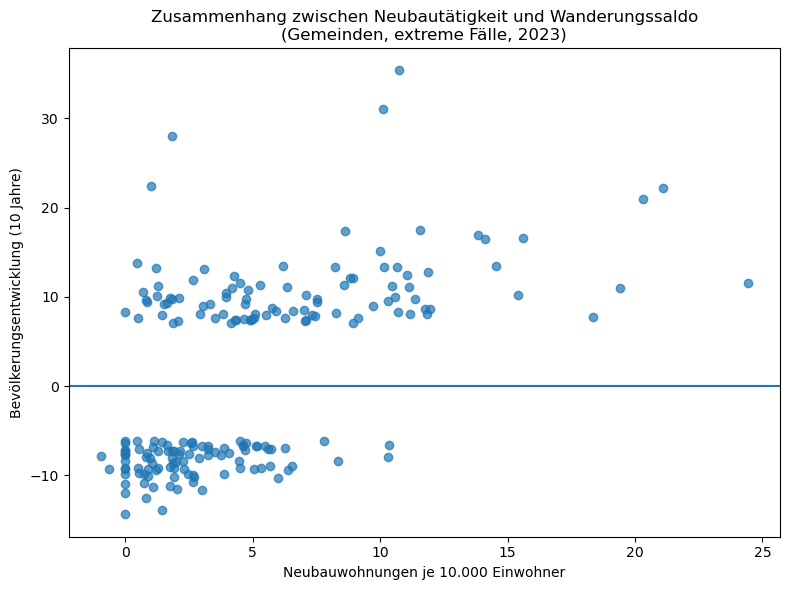

In [123]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df_extreme["Neubauwohnungen je Einwohner"],
    df_extreme["Bevölkerungsentwicklung (10 Jahre)"],
    alpha=0.7
)

plt.axhline(0)
plt.xlabel("Neubauwohnungen je 10.000 Einwohner")
plt.ylabel("Bevölkerungsentwicklung (10 Jahre)")
plt.title("Zusammenhang zwischen Neubautätigkeit und Wanderungssaldo\n(Gemeinden, extreme Fälle, 2023)")

plt.tight_layout()
plt.show()


das war alles nur Vorarbeit, jetzt geht die richtige Analyse los!!  
  
    
  
  
  

  
          
            
# Analyse

1. Ausgangs-DataFrame

In [136]:
inkar_gemeinden_2023

,Kennziffer,Name,Nordbayern,Raumbezug,Zeitbezug,Indikator,Kuerzel,Bereich,ID,Wert
4740,09361000,Amberg,True,Gemeinden,2023,Bevölkerung,a_bb_4G,EU,<NA>,100.0
4741,09361000,Amberg,True,Gemeinden,2023,Bildung,a_bb_4G,EU,<NA>,100.0
4742,09361000,Amberg,True,Gemeinden,2023,Gesundheit,a_bb_4G,EU,<NA>,100.0
4743,09361000,Amberg,True,Gemeinden,2023,Siedlungsstruktur,a_bb_4G,EU,<NA>,100.0
4744,09361000,Amberg,True,Gemeinden,2023,Verkehr,a_bb_4G,EU,<NA>,100.0
...,...,...,...,...,...,...,...,...,...,...
7431206,09679206,"Winterhausen, M",True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,100.0
7431207,09679209,"Zell a.Main, M",True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,100.0
7431208,09679451,Gramschatzer Wald,True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,0.0
7431209,09679452,Guttenberger Wald,True,Gemeinden,2023,Absolutzahlen,a_bb_4G,None,<NA>,0.0


2. relevante Indikatoren angeben und filtern

In [124]:
indikatoren = [
    "Bevölkerungsentwicklung (10 Jahre)",
    "Neubauwohnungen je Einwohner"
]

df_sel = inkar_gemeinden_2023[
    inkar_gemeinden_2023["Indikator"].isin(indikatoren)
].copy()


3. ins wide-format 

In [125]:
df_wide = df_sel.pivot_table(
    index=["Kennziffer", "Name"],
    columns="Indikator",
    values="Wert"
).dropna()


4. Grenzen (Schwellenwerte) bestimmen (Bevölkerungsentwicklung)

In [126]:
q_low = df_wide["Bevölkerungsentwicklung (10 Jahre)"].quantile(0.10)
q_high = df_wide["Bevölkerungsentwicklung (10 Jahre)"].quantile(0.90)


5. Grenzen (Schwellenwerte) bestimmen (Neubau)

In [157]:
NEUBAU_SCHWELLE = 7.02
## Durchschnitt in Bayern

df_wide["Neubau_niveau"] = "wenig"

df_wide.loc[
    df_wide["Neubauwohnungen je Einwohner"] >= NEUBAU_SCHWELLE,
    "Neubau_niveau"
] = "viel"


6. Wachstumsrichtungen

In [158]:
df_wide["Wachstumsrichtung"] = "stabil"

df_wide.loc[
    df_wide["Bevölkerungsentwicklung (10 Jahre)"] > 0,
    "Wachstumsrichtung"
] = "wachsend"

df_wide.loc[
    df_wide["Bevölkerungsentwicklung (10 Jahre)"] < 0,
    "Wachstumsrichtung"
] = "schrumpfend"


7. Extreme weiter kategorisieren (evtl für später)

In [159]:
df_wide["Extrem"] = "mittel"

df_wide.loc[
    df_wide["Bevölkerungsentwicklung (10 Jahre)"] <= q_low,
    "Extrem"
] = "stark schrumpfend"

df_wide.loc[
    df_wide["Bevölkerungsentwicklung (10 Jahre)"] >= q_high,
    "Extrem"
] = "stark wachsend"


8. Typenlogik (!!!)

In [160]:
df_wide["Typ"] = "keine Zuordnung"

# Wachstumsstressräume
df_wide.loc[
    (df_wide["Wachstumsrichtung"] == "wachsend") &
    (df_wide["Neubau_niveau"] == "wenig"),
    "Typ"
] = "Wachstumsstressraum"

# Anpassungsräume
df_wide.loc[
    (df_wide["Wachstumsrichtung"] == "wachsend") &
    (df_wide["Neubau_niveau"] == "viel"),
    "Typ"
] = "Anpassungsraum"

# Stabilisierungsräume
df_wide.loc[
    (df_wide["Wachstumsrichtung"] == "schrumpfend") &
    (df_wide["Neubau_niveau"] == "wenig"),
    "Typ"
] = "Stabilisierungsraum"

# Fehlsteuerungsräume
df_wide.loc[
    (df_wide["Wachstumsrichtung"] == "schrumpfend") &
    (df_wide["Neubau_niveau"] == "viel"),
    "Typ"
] = "Fehlsteuerungsraum"


(9. für Betrachtung extremer Gemeinden)

In [161]:
df_story = df_wide[
    df_wide["Extrem"].isin(["stark wachsend", "stark schrumpfend"])
].copy()


(10. Sanity-Checks)

In [162]:
df_story["Typ"].value_counts()


Typ
Stabilisierungsraum    92
Wachstumsstressraum    52
Anpassungsraum         44
Fehlsteuerungsraum      4
Name: count, dtype: int64

In [163]:
df_story[[
    "Bevölkerungsentwicklung (10 Jahre)",
    "Neubauwohnungen je Einwohner"
]].describe()


Indikator,Bevölkerungsentwicklung (10 Jahre),Neubauwohnungen je Einwohner
count,192.0,192.0
mean,1.37901,4.843281
std,10.458276,4.541365
min,-14.4,-0.96
25%,-7.9575,1.4875
50%,0.47,3.83
75%,9.7225,7.015
max,35.43,24.42


## Story:
### Auf Basis der langfristigen Bevölkerungsentwicklung und der relativen Neubautätigkeit werden Gemeinden in vier Handlungstypen eingeteilt. Der Fokus liegt dabei auf den extremen Wachstums- und Schrumpfungsprozessen.

In [164]:
df_story

,Indikator,Bevölkerungsentwicklung (10 Jahre),Neubauwohnungen je Einwohner,Wachstumsrichtung,Neubau_niveau,Typ,Extrem
Kennziffer,Name,,,,,,
09371123,Gebenbach,-7.48,0.0,schrumpfend,wenig,Stabilisierungsraum,stark schrumpfend
09371129,"Hohenburg, M",10.45,3.94,wachsend,wenig,Wachstumsstressraum,stark wachsend
09371156,"Vilseck, St",7.09,4.14,wachsend,wenig,Wachstumsstressraum,stark wachsend
09372113,Arrach,-7.22,4.7,schrumpfend,wenig,Stabilisierungsraum,stark schrumpfend
09372128,Gleißenberg,-6.98,6.26,schrumpfend,wenig,Stabilisierungsraum,stark schrumpfend
...,...,...,...,...,...,...,...
09679182,"Röttingen, St",-8.42,4.47,schrumpfend,wenig,Stabilisierungsraum,stark schrumpfend
09679187,"Sommerhausen, M",11.35,5.28,wachsend,wenig,Wachstumsstressraum,stark wachsend
09679192,Tauberrettersheim,-7.62,2.5,schrumpfend,wenig,Stabilisierungsraum,stark schrumpfend


## Scatterplot mit Quadranten

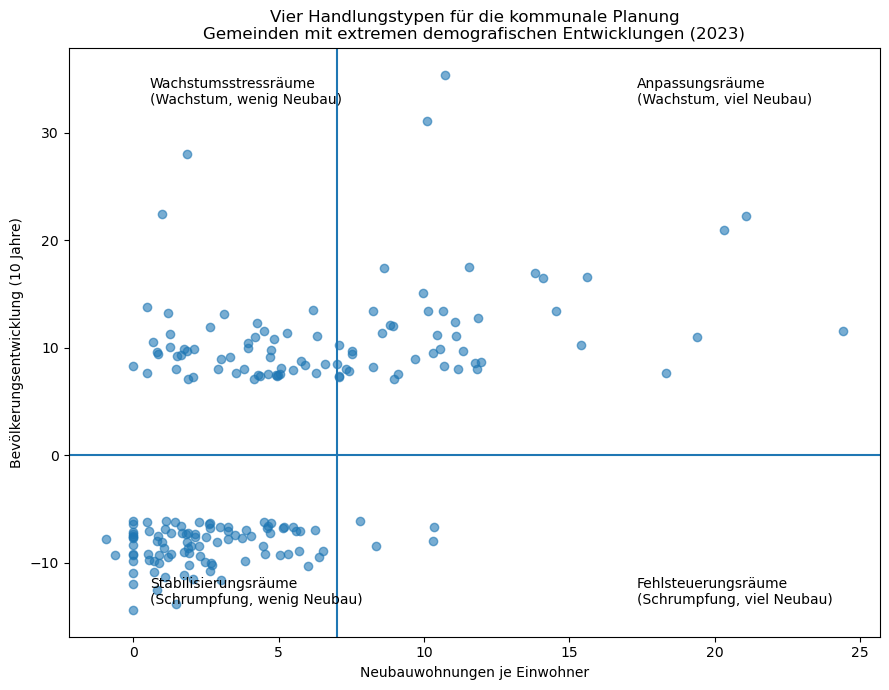

In [166]:
plt.figure(figsize=(9, 7))

plt.scatter(
    df_story["Neubauwohnungen je Einwohner"],
    df_story["Bevölkerungsentwicklung (10 Jahre)"],
    alpha=0.6
)

plt.axhline(0)
plt.axvline(7.02)

# Quadranten-Texte
plt.text(0.1, 0.95, "Wachstumsstressräume\n(Wachstum, wenig Neubau)",
         transform=plt.gca().transAxes, fontsize=10, va="top")

plt.text(0.7, 0.95, "Anpassungsräume\n(Wachstum, viel Neubau)",
         transform=plt.gca().transAxes, fontsize=10, va="top")

plt.text(0.1, 0.05, "Stabilisierungsräume\n(Schrumpfung, wenig Neubau)",
         transform=plt.gca().transAxes, fontsize=10, va="bottom")

plt.text(0.7, 0.05, "Fehlsteuerungsräume\n(Schrumpfung, viel Neubau)",
         transform=plt.gca().transAxes, fontsize=10, va="bottom")

plt.xlabel("Neubauwohnungen je Einwohner")
plt.ylabel("Bevölkerungsentwicklung (10 Jahre)")
plt.title(
    "Vier Handlungstypen für die kommunale Planung\n"
    "Gemeinden mit extremen demografischen Entwicklungen (2023)"
)

plt.tight_layout()
plt.show()


## Scatterplot farblich nach Typ

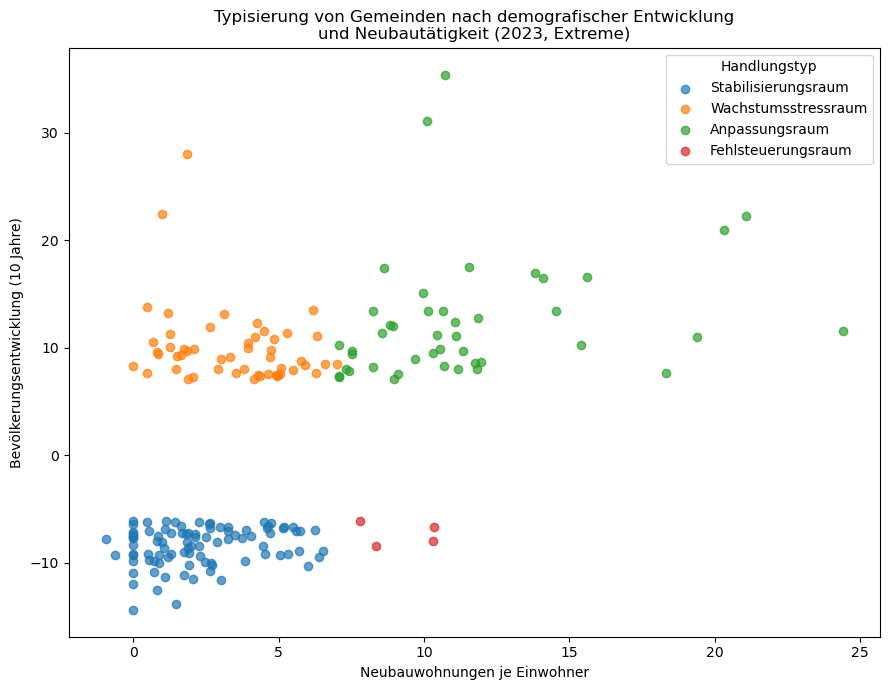

In [170]:
plt.figure(figsize=(9, 7))

for typ in df_story["Typ"].unique():
    subset = df_story[df_story["Typ"] == typ]
    plt.scatter(
        subset["Neubauwohnungen je Einwohner"],
        subset["Bevölkerungsentwicklung (10 Jahre)"],
        label=typ,
        alpha=0.7
    )

plt.xlabel("Neubauwohnungen je Einwohner")
plt.ylabel("Bevölkerungsentwicklung (10 Jahre)")
plt.title(
    "Typisierung von Gemeinden nach demografischer Entwicklung\n"
    "und Neubautätigkeit (2023, Extreme)"
)

plt.legend(title="Handlungstyp")
plt.tight_layout()
plt.show()


## Top 5 Gemeinden jeder Kategorie

In [168]:
top5_list = []

for typ in df_story["Typ"].unique():
    subset = df_story[df_story["Typ"] == typ].copy()

    if typ in ["Wachstumsstressraum", "Anpassungsraum"]:
        subset = subset.sort_values(
            by="Bevölkerungsentwicklung (10 Jahre)",
            ascending=False
        )
    else:
        subset = subset.sort_values(
            by="Bevölkerungsentwicklung (10 Jahre)",
            ascending=True
        )

    top5 = subset.head(5)
    top5["Top_Rang"] = range(1, len(top5) + 1)
    top5_list.append(top5)


C:\Users\Lea\AppData\Local\Temp\ipykernel_26564\4197588534.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5["Top_Rang"] = range(1, len(top5) + 1)
C:\Users\Lea\AppData\Local\Temp\ipykernel_26564\4197588534.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  top5["Top_Rang"] = range(1, len(top5) + 1)
C:\Users\Lea\AppData\Local\Temp\ipykernel_26564\4197588534.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = va

In [169]:
top5_df = (
    pd.concat(top5_list)
      .reset_index()
      .loc[:, [
          "Typ",
          "Top_Rang",
          "Name",
          "Bevölkerungsentwicklung (10 Jahre)",
          "Neubauwohnungen je Einwohner"
      ]]
)


In [146]:
top5_df.sort_values(["Typ", "Top_Rang"])


Indikator,Typ,Top_Rang,Name,Bevölkerungsentwicklung (10 Jahre),Neubauwohnungen je Einwohner
5,Anpassungsraum,1,Irchenrieth,35.43,10.73
6,Anpassungsraum,2,Sengenthal,31.06,10.09
7,Anpassungsraum,3,Deining,22.23,21.08
8,Anpassungsraum,4,"Dombühl, M",20.95,20.31
9,Anpassungsraum,5,Röttenbach,17.54,11.55
10,Fehlsteuerungsraum,1,Henfenfeld,-11.61,3.0
11,Fehlsteuerungsraum,2,Stockheim,-10.3,5.99
12,Fehlsteuerungsraum,3,Großeibstadt,-9.82,3.85
13,Fehlsteuerungsraum,4,Guttenberg,-9.44,6.38
14,Fehlsteuerungsraum,5,Pullenreuth,-9.33,5.05


## vom Verstehen zum Handeln: räumliche Prioritäten

In [143]:
gemeinden_gdf


NameError: name 'gemeinden_gdf' is not defined